In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import plotly.io as pio
from utils import plot_propeller_from_row_plotly, plot_propeller_from_row

In [2]:
# base_path = Path("../results/p200g100_12_02")
base_path = Path("../results/p500g150_2026-01-29")

In [3]:
pareto_path = base_path / "pareto_front.csv"

# Importa os dois CSVs
df_pareto = pd.read_csv(pareto_path)

In [4]:
df_pareto

,generation,pop_index,D,B,hub_radius,number_of_sections,foil_list,chord_list,pitch_list,aerial_rpm,...,aquatic_J,aquatic_CT,aquatic_CQ,aquatic_CP,aquatic_eta,cavitating_proportion,QI,aquatic_fitness,cavitation_penalty,aquatic_solidity_penalty
0,NaN,NaN,0.254,2,0.00825,20,E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E6...,0.009376262058272166;0.010911658288531505;0.01...,7.913405643578076;8.367491413395525;8.36749141...,4000.0,...,0.0,0.242791,0.009413,0.059143,0.0,0.65,1.613947,0.564881,0.65,0.000000
1,NaN,NaN,0.254,2,0.00825,20,E63;NACA0018;E63;E63;E63;E63;E63;E63;E63;E63;E...,0.008679985694352263;0.009319923850549557;0.00...,7.657942405682956;7.477875326858465;7.47787532...,4000.0,...,0.0,0.228410,0.008778,0.055151,0.0,0.60,1.579270,0.631708,0.60,0.000000
2,NaN,NaN,0.254,2,0.00825,20,E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E6...,0.011775736879348294;0.010932834056867088;0.01...,7.362096291172989;7.996112835916979;7.45870753...,4000.0,...,0.0,0.234955,0.009069,0.056983,0.0,0.60,1.594684,0.637874,0.60,0.000000
3,NaN,NaN,0.254,3,0.00825,20,NACA4412;E63;E63;E63;E63;E63;E63;E63;E63;E63;E...,0.010917923679180274;0.010917923679180274;0.01...,7.9160901803804435;7.9160901803804435;7.947104...,4000.0,...,0.0,0.266469,0.010747,0.067525,0.0,0.60,1.625353,0.650141,0.60,0.000000
4,NaN,NaN,0.254,3,0.00825,20,E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E6...,0.009482612906191113;0.009482612906191113;0.00...,7.379427675836529;7.379427675836529;6.24755408...,4000.0,...,0.0,0.258345,0.010213,0.064172,0.0,0.60,1.632661,0.653064,0.60,0.000000
5,NaN,NaN,0.254,3,0.00825,20,NACA0018;E63;E63;E63;E63;E63;E63;E63;E63;E63;E...,0.009482612906191113;0.008951566649866046;0.00...,7.083790262627823;6.517853469296652;6.51785346...,4000.0,...,0.0,0.263221,0.010390,0.065283,0.0,0.60,1.650532,0.660213,0.60,0.000000
6,NaN,NaN,0.254,3,0.00825,20,E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E6...,0.009794671277373573;0.010400159962596998;0.01...,7.9209757783275005;8.203527935166363;7.9471049...,4000.0,...,0.0,0.273001,0.010916,0.068586,0.0,0.60,1.659400,0.663760,0.60,0.000000
7,NaN,NaN,0.254,3,0.00825,20,E63;E63;NACA0018;NACA0018;E63;E63;E63;E63;E63;...,0.010422655116305985;0.011537093257619691;0.01...,10.0;8.535860598204927;8.535860598204927;7.811...,4000.0,...,0.0,0.277168,0.011094,0.069708,0.0,0.60,1.670207,0.668083,0.60,0.000000
8,NaN,NaN,0.254,3,0.00825,20,E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E63;E6...,0.009482612906191113;0.009482612906191113;0.00...,7.379427675836529;7.379427675836529;6.24755408...,4000.0,...,0.0,0.278114,0.011042,0.069378,0.0,0.60,1.686760,0.674704,0.60,0.000000
9,NaN,NaN,0.254,3,0.00825,20,NACA0018;NACA0018;E63;E63;E63;E63;E63;E63;E63;...,0.008546131334045066;0.01006067022945089;0.010...,7.265254708969202;7.7799514537142525;7.7799514...,4000.0,...,0.0,0.281523,0.011210,0.070435,0.0,0.60,1.692090,0.676836,0.60,0.000000


In [5]:
df_pareto[["aerial_fitness", "aquatic_fitness"]]

,aerial_fitness,aquatic_fitness
0,1.540984,0.564881
1,1.504506,0.631708
2,1.431621,0.637874
3,1.389224,0.650141
4,1.346785,0.653064
5,1.239027,0.660213
6,1.219918,0.663760
7,1.217957,0.668083
8,1.145966,0.674704
9,1.061100,0.676836


In [6]:
# candidate = 0

# row = df_pareto.iloc[candidate]

# pio.renderers.default = "browser"  # ou "svg", "png", "json", etc.

# fig = plot_propeller_from_row_plotly(row, title_suffix="Hydrone Candidate #{}".format(candidate))
# fig.show()

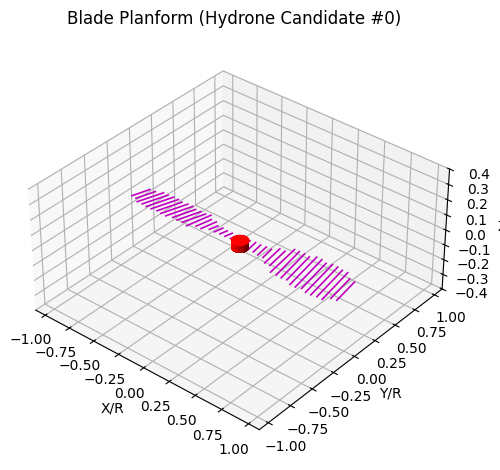

In [7]:
# Best aerial

candidate = 0

row = df_pareto.iloc[candidate]

fig = plot_propeller_from_row(row, title_suffix="Hydrone Candidate #{}".format(candidate))


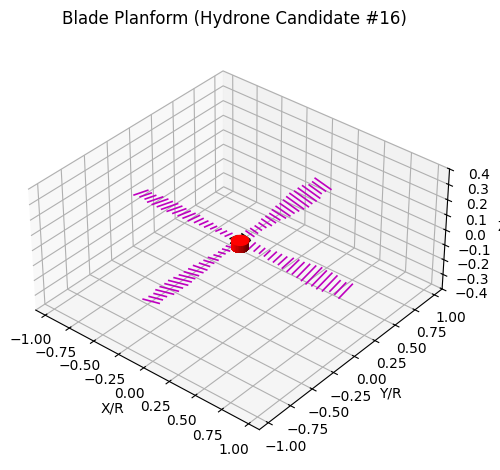

In [8]:
# intermediate

candidate = 16

row = df_pareto.iloc[candidate]

fig = plot_propeller_from_row(row, title_suffix="Hydrone Candidate #{}".format(candidate))

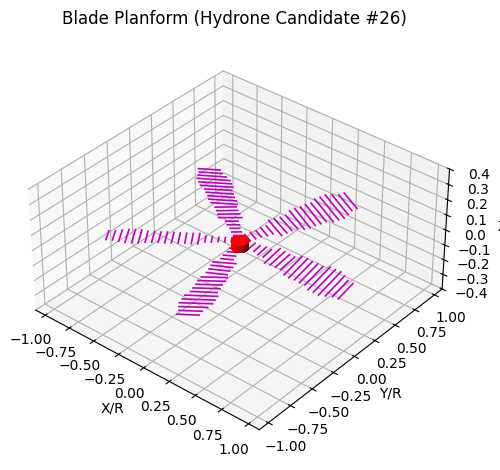

In [9]:
# Best aquatic

candidate = 26

row = df_pareto.iloc[candidate]

fig = plot_propeller_from_row(row, title_suffix="Hydrone Candidate #{}".format(candidate))